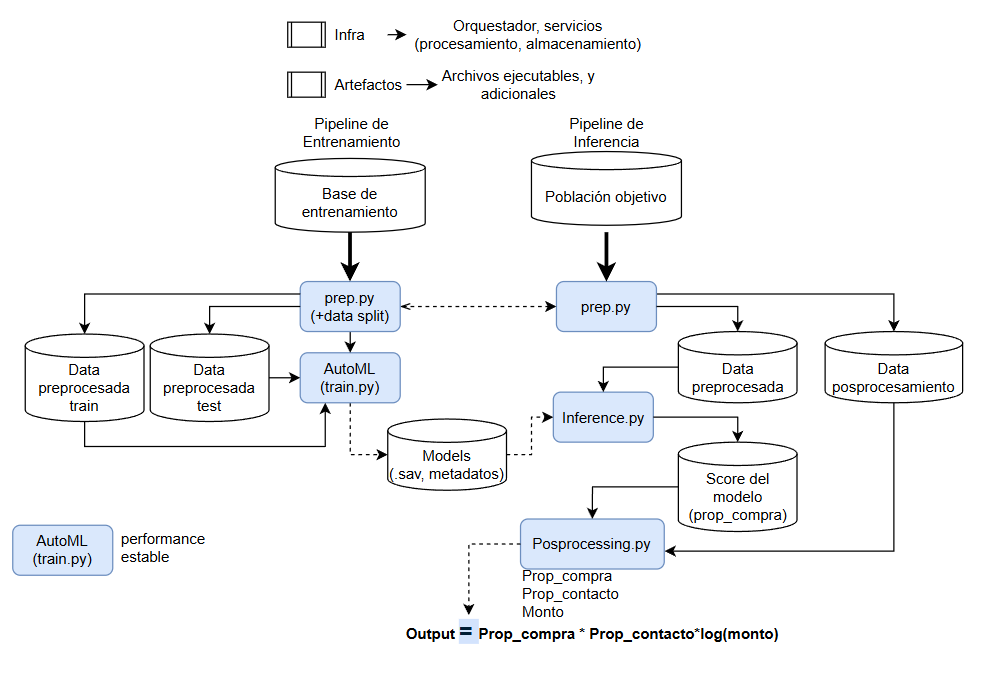

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import sys
sys.path.append('/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Códigos')

import preprocessing as prep
import training as aml #training simple sin ajuste de HPO
import hpo as aml2

# ***ORQUESTADOR***

In [8]:
# RUTAS INPUT DEL PREPROCESSING JOB ====================================================
DIR_RAWDATA = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Data Cruda'
DIR_TRAINING = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Data Entrenamiento'

# RUTAS OUTPUT DEL PREPROCESSING JOB =====================================================
DIR_PROCESSED = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Data Preprocesada'

# RUTAS INPUT DEL TRAINING JOB ====================================================
DATA_TRAIN_PATH = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Data Preprocesada/training_data/preprocessed/train_vars_extrac.csv'
DATA_TEST_PATH = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Data Preprocesada/training_data/preprocessed/test_vars_extrac.csv'

# RUTAS OUTPUT DEL TRAINING JOB =====================================================
MODEL_DIR = '/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Modelo'


In [5]:
#prep.main('extrac', DIR_RAWDATA, DIR_PROCESSED, 'inference',  5) #inference
prep.main('extrac', DIR_TRAINING, DIR_PROCESSED, 'training') #training

#En la carpeta DIR_TRAINING colocar la data cruda para entrenar.

Successfully unified dataframes.


In [9]:
aml.main(DATA_TRAIN_PATH, DATA_TEST_PATH, MODEL_DIR)

Directorio de modelos guardado en: /content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Modelo/2026-05-06_02-07-17


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:07:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: xgb
  AUC Train: 0.8882
  AUC Test: 0.8476
  Decay (%): 4.57%
--------------------
[LightGBM] [Info] Number of positive: 33815, number of negative: 1025262
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.487448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9397
[LightGBM] [Info] Number of data points in the train set: 1059077, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.031929 -> initscore=-3.411799
[LightGBM] [Info] Start training from score -3.411799
Model: lgbm
  AUC Train: 0.8683
  AUC Test: 0.8529
  Decay (%): 1.77%
--------------------
Model: catb
  AUC Train: 0.8587
  AUC Test: 0.8525
  Decay (%): 0.73%
--------------------

Modelo finalista: lgbm
Modelo guardado en: /content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Modelo/2026-05-06_02-07-17/lgbm_mod

In [ ]:
aml2.main(DATA_TRAIN_PATH, DATA_TEST_PATH, MODEL_DIR)

Directorio de modelos guardado en: /content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Datos/Modelo/2026-05-06_02-15-45

--- Iniciando HPO para: XGB ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:57:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Resultados HPO para: xgb
  Mejor AUC en Cross-Validation: 0.8536
  Mejores Parámetros: {'colsample_bytree': np.float64(0.7692681476866446), 'learning_rate': np.float64(0.05820509320520235), 'max_depth': 6, 'n_estimators': 363, 'subsample': np.float64(0.7103165563345655)}
  AUC Train (con mejor modelo): 0.8855
  AUC Test (con mejor modelo): 0.8550
  Decay (%): 3.45%
--------------------

--- Iniciando HPO para: LGBM ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Resultados HPO para: lgbm
  Mejor AUC en Cross-Validation: 0.8533
  Mejores Parámetros: {'colsample_bytree': np.float64(0.7975990992289792), 'learning_rate': np.float64(0.0877354579378964), 'max_depth': 4, 'n_estimators': 466, 'num_leaves': 40, 'subsample': np.float64(0.8760253496991544)}
  AUC Train (con mejor modelo): 0.8705
  AUC Test (con mejor modelo): 0.8548
  Decay (%): 1.80%
--------------------

--- Iniciando HPO para: CATB ---
Fitting 3 folds for each of 15 candidates, totalling 45 fits
